# Codveda Data Analytics Internship — Level 1 (Basic)
**Intern submission · Codveda Technology**

This notebook contains all three Level 1 tasks:
1. **Data Cleaning & Preprocessing** — on the raw social-media *Sentiment* dataset
2. **Exploratory Data Analysis (EDA)** — on the *Iris* dataset
3. **Basic Data Visualization** — on the *Iris* dataset

All generated figures are also exported to `outputs/` as PNGs for the report/video.

In [1]:
# --- Setup: imports, paths, plot style ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Datasets live in the sibling "Data Set For Task" folder; fall back to absolute path.
DATA_DIR = Path("../../Data Set For Task")
if not DATA_DIR.exists():
    DATA_DIR = Path("/home/magzm/Codveda/Data Set For Task")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
print("Data dir:", DATA_DIR.resolve())

Data dir: /home/magzm/Codveda/Data Set For Task


---
## Task 1 — Data Cleaning and Preprocessing

**Dataset:** `3) Sentiment dataset.csv` — raw social-media posts with leading/trailing
whitespace, redundant unnamed index columns, and inconsistent categorical labels.

**Workflow:** inspect → drop redundant columns → strip/standardize text & categoricals →
handle missing values → remove duplicates → standardize date formats → save cleaned file.

In [2]:
# Load the raw dataset and inspect its issues
raw = pd.read_csv(DATA_DIR / "3) Sentiment dataset.csv")
print("Raw shape:", raw.shape)
print("\nColumns:", list(raw.columns))
raw.head(3)

Raw shape: (732, 15)

Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


In [3]:
# Quick diagnostic of data-quality issues
print("Missing values per column:\n", raw.isnull().sum())
print("\nFully-duplicated rows:", raw.duplicated().sum())
print("\nUnique Sentiment labels (raw, with whitespace):", raw['Sentiment'].nunique())
# The two 'Unnamed' columns are leftover row indices from a prior export -> redundant
print("Redundant index-like columns:", [c for c in raw.columns if c.startswith('Unnamed')])

Missing values per column:
 Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Fully-duplicated rows: 0

Unique Sentiment labels (raw, with whitespace): 279
Redundant index-like columns: ['Unnamed: 0.1', 'Unnamed: 0']


In [4]:
df = raw.copy()

# 1) Drop redundant unnamed index columns
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])

# 2) Standardize inconsistent text formats: strip whitespace on all object (text) columns
obj_cols = df.select_dtypes(include='object').columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

# 3) Standardize categorical variables (consistent casing for grouping fields)
for c in ['Sentiment', 'Platform', 'Country']:
    df[c] = df[c].str.title()

print("After stripping, unique Sentiment labels:", df['Sentiment'].nunique())
df[['Text', 'Sentiment', 'Platform', 'Country']].head(3)

After stripping, unique Sentiment labels: 191


/tmp/claude-1000/ipykernel_3633/2829892708.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns


,Text,Sentiment,Platform,Country
0,Enjoying a beautiful day at the park!,Positive,Twitter,Usa
1,Traffic was terrible this morning.,Negative,Twitter,Canada
2,Just finished an amazing workout! 💪,Positive,Instagram,Usa


In [5]:
# 4) Handle missing values
#    Numeric -> median imputation; categorical/text -> mode (most frequent).
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])
print("Missing values remaining:", int(df.isnull().sum().sum()))

Missing values remaining: 0


/tmp/claude-1000/ipykernel_3633/3986182791.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [6]:
# 5) Remove duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")

# 6) Standardize date formats -> proper datetime, then a clean ISO date column
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Date'] = df['Timestamp'].dt.strftime('%Y-%m-%d')
print("Timestamp dtype:", df['Timestamp'].dtype)
df[['Timestamp', 'Date']].head(3)

Removed 22 duplicate rows. New shape: (710, 13)
Timestamp dtype: datetime64[us]


,Timestamp,Date
0,2023-01-15 12:30:00,2023-01-15
1,2023-01-15 08:45:00,2023-01-15
2,2023-01-15 15:45:00,2023-01-15


In [7]:
# 7) Map the 279 fine-grained emotion labels to 3 canonical sentiment classes.
#    (Useful downstream for the Level 3 NLP task.)
POS = {'Positive','Joy','Excitement','Contentment','Gratitude','Happy','Happiness',
       'Serenity','Love','Hope','Pride','Admiration','Elation','Enthusiasm','Euphoria'}
NEG = {'Negative','Despair','Sadness','Anger','Fear','Frustration','Loneliness',
       'Grief','Disgust','Bitterness','Bad','Hate','Regret','Anxiety'}
def to_class(s):
    if s in POS: return 'Positive'
    if s in NEG: return 'Negative'
    return 'Neutral'
df['Sentiment_Class'] = df['Sentiment'].apply(to_class)
print(df['Sentiment_Class'].value_counts())

# Save the cleaned dataset
clean_path = "cleaned_sentiment.csv"
df.to_csv(clean_path, index=False)
print("\nSaved cleaned dataset ->", clean_path, "| shape:", df.shape)

Sentiment_Class
Neutral     401
Positive    235
Negative     74
Name: count, dtype: int64

Saved cleaned dataset -> cleaned_sentiment.csv | shape: (710, 15)


**Task 1 summary:** removed redundant index columns, stripped whitespace across all
text fields, standardized categorical casing, imputed any missing values (median/mode),
dropped duplicates, parsed timestamps into proper datetimes, and produced a tidy
`cleaned_sentiment.csv` with an added 3-class `Sentiment_Class` label.

---
## Task 2 — Exploratory Data Analysis (EDA)

**Dataset:** `1) iris.csv` — 150 flowers, 4 numeric features, 3 species.
Goal: summary statistics, distribution plots, and correlations.

In [8]:
iris = pd.read_csv(DATA_DIR / "1) iris.csv")
print("Shape:", iris.shape)
iris.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
# Summary statistics: mean, median, mode, std (+ pandas describe)
num = iris.select_dtypes(include=np.number)
summary = pd.DataFrame({
    'mean':   num.mean(),
    'median': num.median(),
    'mode':   num.mode().iloc[0],
    'std':    num.std(),
})
print("Per-feature summary statistics:")
print(summary.round(3))
print("\nSpecies counts:\n", iris['species'].value_counts())
iris.describe().round(3)

Per-feature summary statistics:
               mean  median  mode    std
sepal_length  5.843    5.80   5.0  0.828
sepal_width   3.054    3.00   3.0  0.434
petal_length  3.759    4.35   1.5  1.764
petal_width   1.199    1.30   0.2  0.763

Species counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.054,3.759,1.199
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


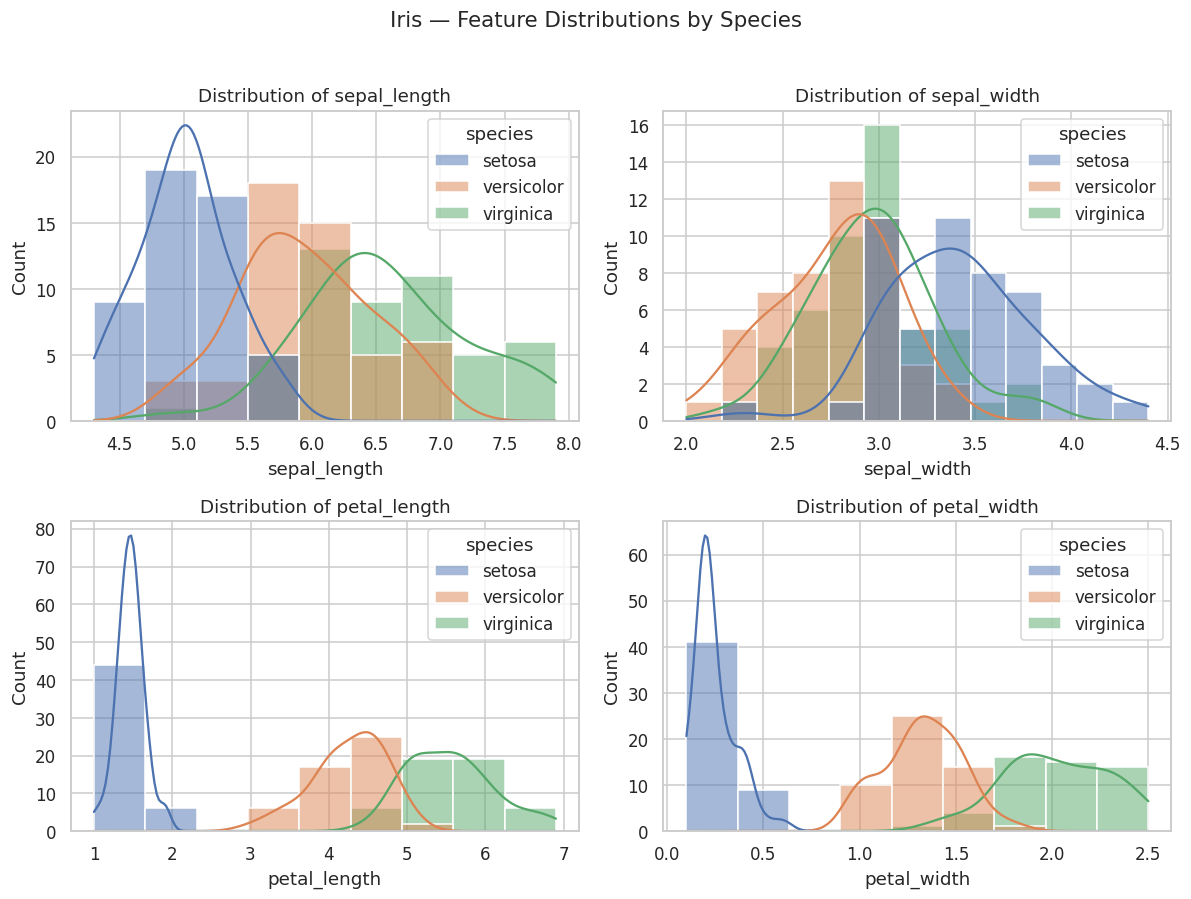

In [10]:
# Distributions: histograms for each feature
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), num.columns):
    sns.histplot(data=iris, x=col, hue='species', kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
fig.suptitle("Iris — Feature Distributions by Species", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT / "eda_histograms.png", bbox_inches='tight')
plt.show()

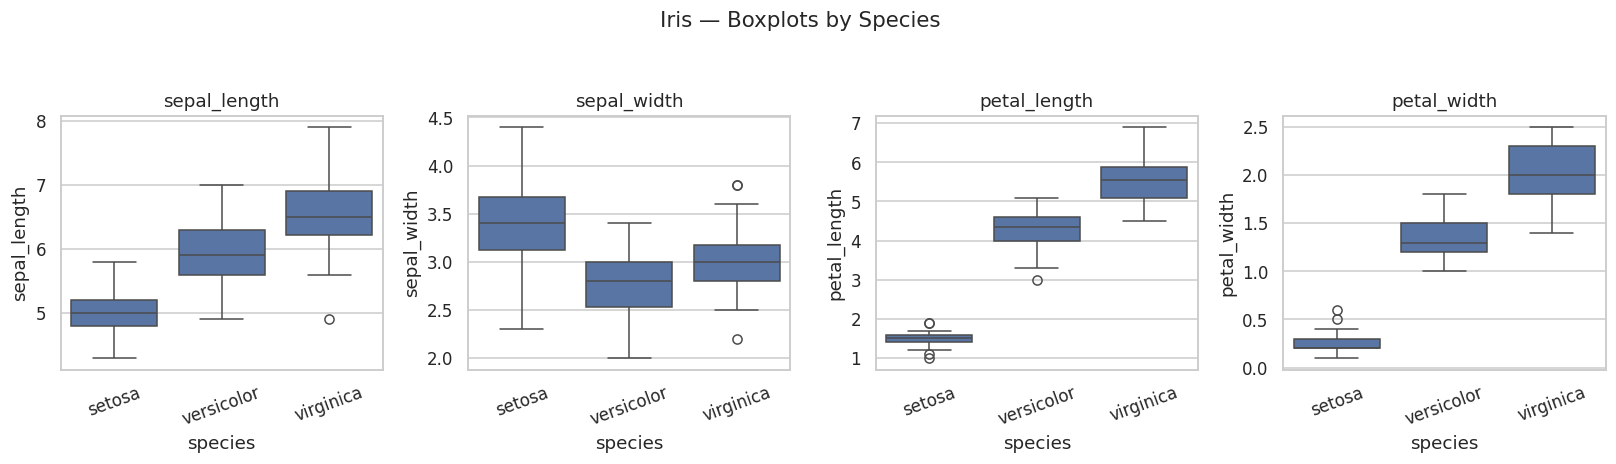

In [11]:
# Distributions: boxplots to spot spread and outliers
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num.columns):
    sns.boxplot(data=iris, x='species', y=col, ax=ax)
    ax.set_title(col); ax.tick_params(axis='x', rotation=20)
fig.suptitle("Iris — Boxplots by Species", fontsize=14, y=1.05)
fig.tight_layout()
fig.savefig(OUT / "eda_boxplots.png", bbox_inches='tight')
plt.show()

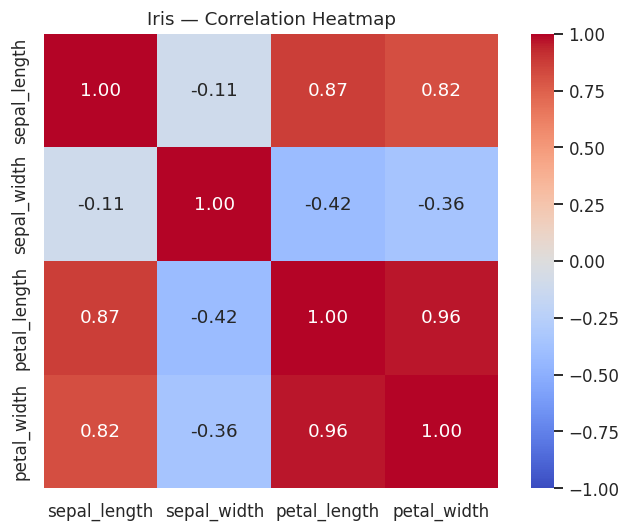

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.109         0.872        0.818
sepal_width         -0.109        1.000        -0.421       -0.357
petal_length         0.872       -0.421         1.000        0.963
petal_width          0.818       -0.357         0.963        1.000


In [12]:
# Correlations between numerical features
corr = num.corr()
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title("Iris — Correlation Heatmap")
plt.tight_layout()
plt.savefig(OUT / "eda_correlation_heatmap.png", bbox_inches='tight')
plt.show()
print(corr.round(3))

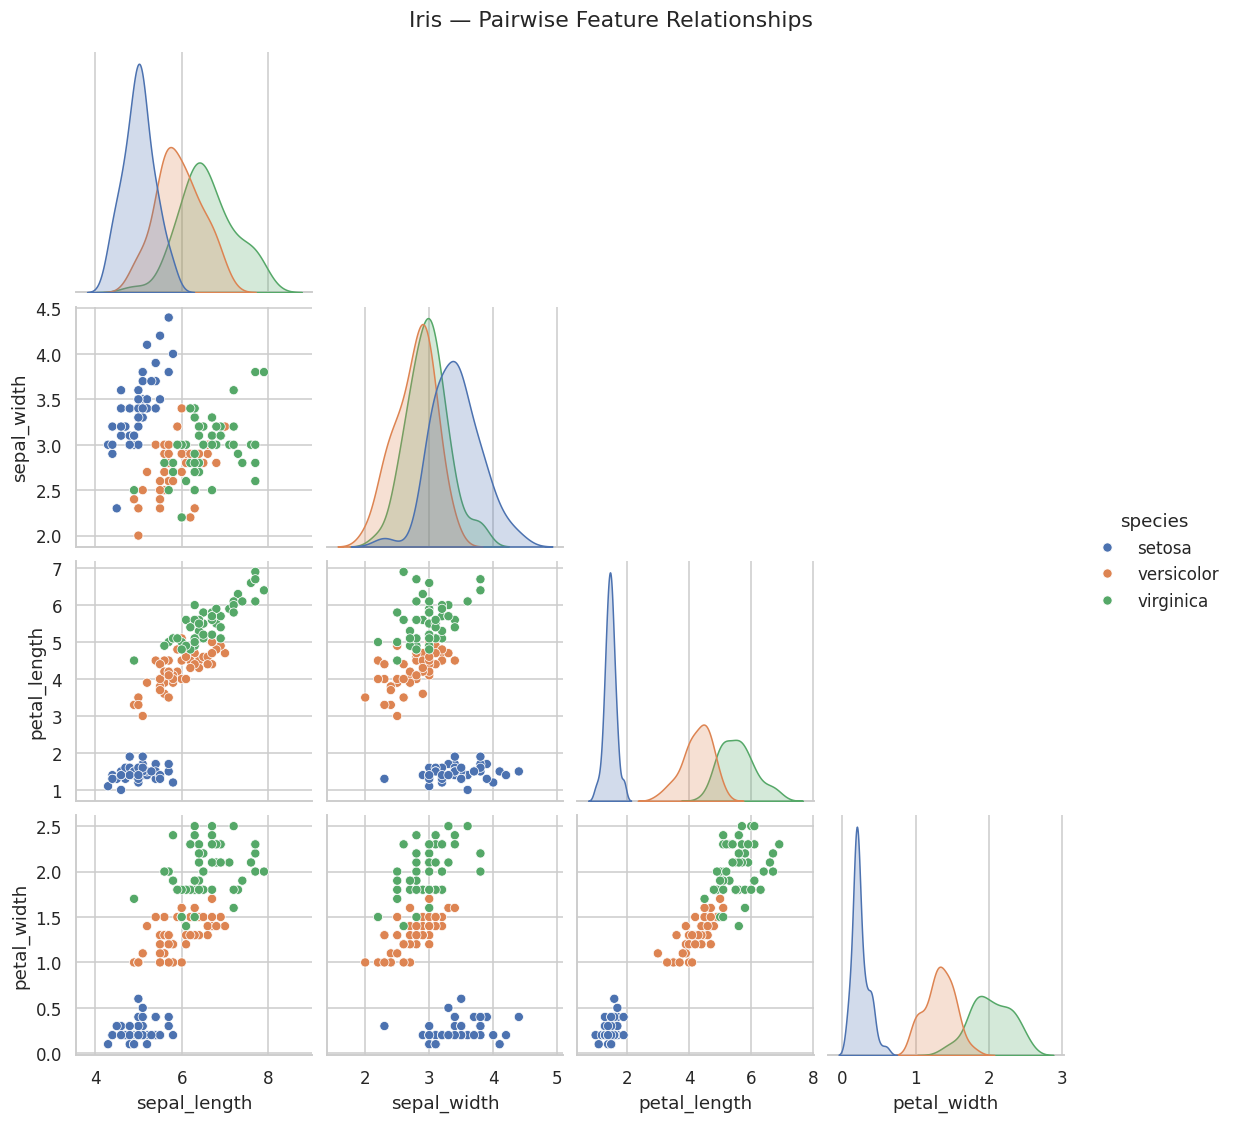

In [13]:
# Pairwise relationships (scatter matrix)
pp = sns.pairplot(iris, hue='species', corner=True, diag_kind='kde')
pp.fig.suptitle("Iris — Pairwise Feature Relationships", y=1.02)
pp.savefig(OUT / "eda_pairplot.png", bbox_inches='tight')
plt.show()

**EDA observations:**
- `petal_length` and `petal_width` are very strongly correlated (~0.96) and separate the
  species cleanly — *setosa* is clearly distinct, *versicolor* and *virginica* overlap.
- Sepal measurements overlap much more across species and are weaker discriminators.
- Distributions are roughly bell-shaped per species; few outliers (visible in boxplots).

---
## Task 3 — Basic Data Visualization

**Dataset:** `1) iris.csv`. Goal: bar, line, and scatter charts with customized
labels/titles/legends, each exported as a PNG.

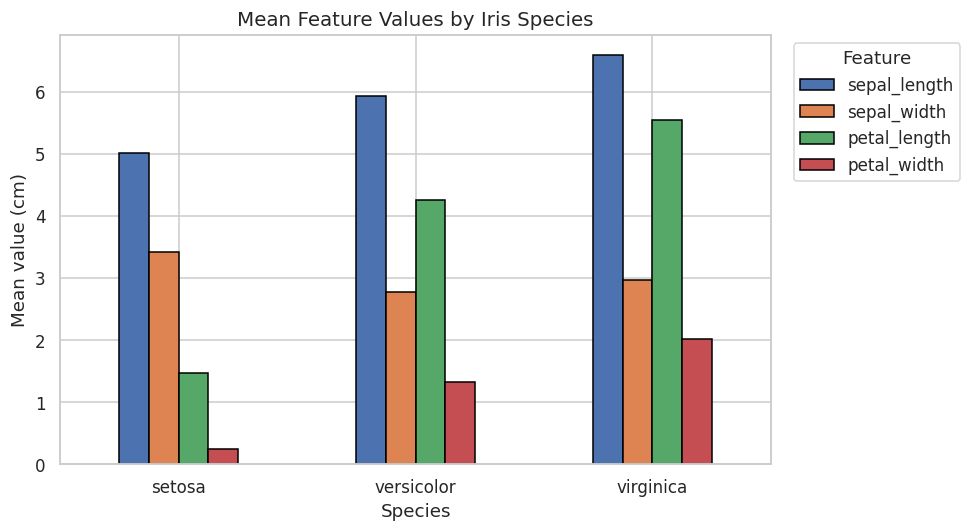

In [14]:
# Bar chart — mean of each feature per species
mean_by_species = iris.groupby('species')[num.columns].mean()
ax = mean_by_species.plot(kind='bar', figsize=(9, 5), edgecolor='black')
ax.set_title("Mean Feature Values by Iris Species", fontsize=13)
ax.set_xlabel("Species"); ax.set_ylabel("Mean value (cm)")
ax.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT / "viz_bar_mean_by_species.png", bbox_inches='tight')
plt.show()

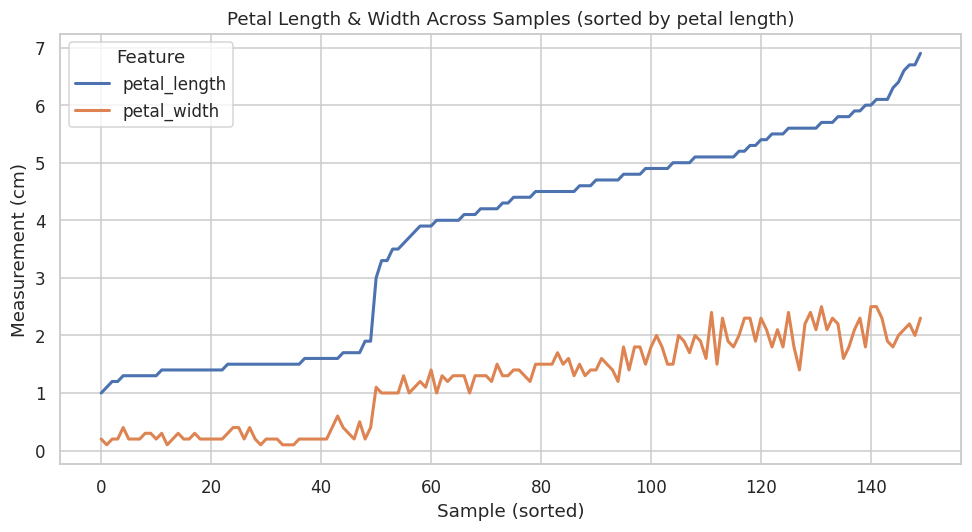

In [15]:
# Line chart — sorted petal length showing the gradient across the dataset
ordered = iris.sort_values('petal_length').reset_index(drop=True)
plt.figure(figsize=(9, 5))
plt.plot(ordered.index, ordered['petal_length'], label='petal_length', lw=2)
plt.plot(ordered.index, ordered['petal_width'], label='petal_width', lw=2)
plt.title("Petal Length & Width Across Samples (sorted by petal length)")
plt.xlabel("Sample (sorted)"); plt.ylabel("Measurement (cm)")
plt.legend(title="Feature")
plt.tight_layout()
plt.savefig(OUT / "viz_line_petal.png", bbox_inches='tight')
plt.show()

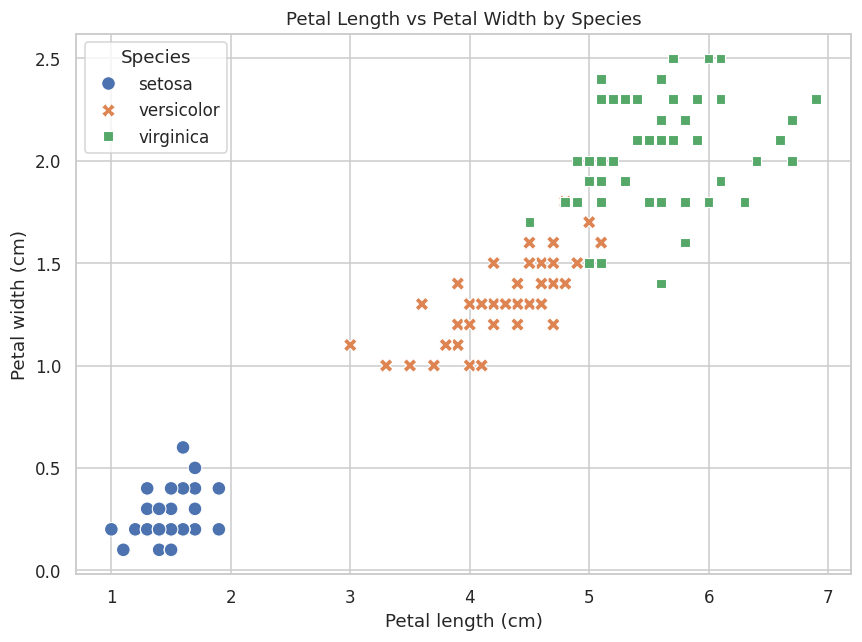

In [16]:
# Scatter plot — petal length vs width, colored by species
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', style='species', s=80)
plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal length (cm)"); plt.ylabel("Petal width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.savefig(OUT / "viz_scatter_petal.png", bbox_inches='tight')
plt.show()

**Task 3 summary:** produced customized bar, line, and scatter charts (titles, axis
labels, legends) and exported each to `outputs/`. The scatter clearly shows *setosa*
forming a separate cluster, consistent with the EDA findings.

---
### Level 1 complete ✅
Cleaned dataset saved as `cleaned_sentiment.csv`; all figures in `outputs/`.